# Evaluación clínica y toma de decisión

Este notebook contiene la capa avanzada de evaluación clínica del proyecto de predicción de cáncer. Complementa a `modelo.ipynb` y puede ejecutarse de dos formas:

- **Mismo kernel que `modelo.ipynb`:** ejecuta primero el notebook principal hasta la Fase 7 y después empieza directamente en el Bloque 1.
- **Kernel limpio:** ejecuta primero el setup rápido de abajo. Ese bloque reconstruye desde `data/cancer_dataset_unido.csv` los objetos necesarios para esta evaluación.

La idea es separar el modelado técnico de la toma de decisión clínica: umbrales, incertidumbre, calibración, robustez, interpretabilidad, sesgo, leakage, impacto operativo y coste-beneficio.


## Setup rápido si el kernel está limpio

Si este notebook se ejecuta en el mismo kernel que `modelo.ipynb`, puedes saltarte la reconstrucción de modelos. Si aparece un error indicando que faltan variables como `mlp_model`, `threshold_results` o `metricas_finales`, ejecuta la siguiente celda: reconstruye desde `data/cancer_dataset_unido.csv` los objetos necesarios para la evaluación clínica.

Este notebook queda alineado con `modelo.ipynb`: el modelo operativo por defecto es `HistGradientBoosting` con umbral optimizado en validación. La MLP se mantiene como comparador.

Las gráficas se guardan automáticamente en `figures/evaluacion_clinica/`.


In [23]:
# Setup rápido para ejecutar este notebook de forma independiente
# Ejecutar solo si NO vienes del mismo kernel donde ya corriste modelo.ipynb hasta Fase 7.
import os
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

from functools import reduce
from keras import layers, regularizers
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

if "mlp_model" in globals() and "threshold_results" in globals() and "metricas_finales" in globals():
    print("Variables principales ya existen en memoria. No se reconstruye nada.")
else:
    RANDOM_STATE = 42
    TARGET = "cancer"
    ID_COL = "paciente_id"
    leakage_or_postdiagnosis_features = ["coste_total", "coste_farmaco", "num_ingresos", "dias_hospital", "vive", "alcohol"]

    df_cancer = pd.read_csv("data/cancer_dataset_unido.csv")
    excluded_features = [TARGET, ID_COL] + leakage_or_postdiagnosis_features
    X = df_cancer.drop(columns=excluded_features)
    y = df_cancer[TARGET].astype(int)

    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ],
        remainder="drop",
    )
    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()

    mejor_modelo_ml_nombre = "HistGradientBoosting"
    mejor_modelo_ml = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, l2_regularization=0.1,
        class_weight="balanced", random_state=RANDOM_STATE
    )
    mejor_modelo_ml.fit(X_train_prep, y_train)
    y_test_proba_ml = mejor_modelo_ml.predict_proba(X_test_prep)[:, 1]

    # Modelo de árboles auxiliar para interpretabilidad.
    modelo_importancia_nombre = "Extra Trees"
    modelo_importancia = ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE
    )
    modelo_importancia.fit(X_train_prep, y_train)

    keras.utils.set_random_seed(RANDOM_STATE)
    input_dim = X_train_prep.shape[1]
    class_weights_array = compute_class_weight(
        class_weight="balanced", classes=np.array([0, 1]), y=y_train
    )
    class_weight = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}

    def crear_modelo_mlp(input_dim):
        modelo = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(), layers.Activation("relu"), layers.Dropout(0.25),
            layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(), layers.Activation("relu"), layers.Dropout(0.25),
            layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(), layers.Activation("relu"), layers.Dropout(0.20),
            layers.Dense(1, activation="sigmoid"),
        ])
        modelo.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc"),
                     keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
        )
        return modelo

    mlp_model = crear_modelo_mlp(input_dim)
    X_train_mlp = X_train_prep.astype("float32")
    y_train_mlp = y_train.to_numpy().astype("float32")
    X_mlp_train, X_mlp_val, y_mlp_train, y_mlp_val = train_test_split(
        X_train_mlp, y_train_mlp, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
    )
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True, verbose=0
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5, verbose=0
    )
    history_mlp = mlp_model.fit(
        X_mlp_train, y_mlp_train, validation_data=(X_mlp_val, y_mlp_val),
        epochs=100, batch_size=256, class_weight=class_weight,
        callbacks=[early_stopping, reduce_lr], verbose=0
    )

    thresholds = np.arange(0.10, 0.91, 0.01)

    def evaluar_thresholds(y_true, y_proba, nombre_modelo):
        filas = []
        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            filas.append({
                "modelo": nombre_modelo,
                "threshold": threshold,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            })
        return pd.DataFrame(filas)

    y_val_proba_mlp = mlp_model.predict(X_mlp_val, verbose=0).ravel()
    threshold_results_mlp = evaluar_thresholds(y_mlp_val, y_val_proba_mlp, "MLP")
    best_threshold_mlp = float(threshold_results_mlp.sort_values("f1", ascending=False).iloc[0]["threshold"])

    modelo_ml_para_umbral = clone(mejor_modelo_ml)
    modelo_ml_para_umbral.fit(X_mlp_train, y_mlp_train.astype(int))
    y_val_proba_ml = modelo_ml_para_umbral.predict_proba(X_mlp_val)[:, 1]
    threshold_results_ml = evaluar_thresholds(y_mlp_val.astype(int), y_val_proba_ml, mejor_modelo_ml_nombre)
    best_threshold_ml = float(threshold_results_ml.sort_values("f1", ascending=False).iloc[0]["threshold"])
    threshold_ml = best_threshold_ml

    threshold_results = pd.concat([threshold_results_ml, threshold_results_mlp], ignore_index=True)
    threshold_results_operativo = threshold_results_ml.copy()

    y_test_proba_mlp = mlp_model.predict(X_test_prep.astype("float32"), verbose=0).ravel()

    def calcular_metricas(nombre, y_true, y_proba, threshold):
        y_pred = (y_proba >= threshold).astype(int)
        return {
            "modelo": nombre, "threshold": threshold,
            "precision_cancer_1": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancer_1": recall_score(y_true, y_pred, zero_division=0),
            "f1_cancer_1": f1_score(y_true, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
        }
    metricas_finales = pd.DataFrame([
        calcular_metricas(mejor_modelo_ml_nombre, y_test, y_test_proba_ml, best_threshold_ml),
        calcular_metricas("MLP", y_test, y_test_proba_mlp, best_threshold_mlp),
    ])
    modelo_operativo_nombre = mejor_modelo_ml_nombre
    y_test_proba_operativo = y_test_proba_ml
    threshold_operativo = best_threshold_ml
    y_test_pred_operativo = (y_test_proba_operativo >= threshold_operativo).astype(int)
    y_test_pred_mlp = (y_test_proba_mlp >= best_threshold_mlp).astype(int)

    print("Setup completado desde CSV local.")
    print(f"Best threshold {mejor_modelo_ml_nombre}: {best_threshold_ml:.2f}")
    print(f"Best threshold MLP: {best_threshold_mlp:.2f}")
    display(metricas_finales)

# Normalización de variables operativas si vienes desde `modelo.ipynb`.
if "best_threshold_ml" in globals():
    threshold_ml = best_threshold_ml
if "modelo_operativo_nombre" not in globals() and "mejor_modelo_ml_nombre" in globals():
    modelo_operativo_nombre = mejor_modelo_ml_nombre
if "y_test_proba_operativo" not in globals() and "y_test_proba_ml" in globals():
    y_test_proba_operativo = y_test_proba_ml
if "threshold_operativo" not in globals() and "threshold_ml" in globals():
    threshold_operativo = threshold_ml
if "y_test_pred_operativo" not in globals() and "y_test_proba_operativo" in globals():
    y_test_pred_operativo = (y_test_proba_operativo >= threshold_operativo).astype(int)
if "threshold_results_operativo" not in globals() and "threshold_results" in globals():
    if "modelo" in threshold_results.columns and "modelo_operativo_nombre" in globals():
        threshold_results_operativo = threshold_results[threshold_results["modelo"] == modelo_operativo_nombre].copy()
    else:
        threshold_results_operativo = threshold_results.copy()


Variables principales ya existen en memoria. No se reconstruye nada.


## Configuración de salida de gráficas

Todas las figuras de la evaluación clínica se exportan como PNG en `figures/evaluacion_clinica/` para poder incluirlas en memoria, README o presentación.


In [24]:
# Carpeta de salida para las gráficas de este notebook
from pathlib import Path

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Las gráficas se guardarán en: {FIG_DIR.resolve()}")


Las gráficas se guardarán en: /Users/maria/Desktop/CASO CÁNCER/figures/evaluacion_clinica


## 1. Políticas de decisión basadas en umbral

Se analizan varias políticas de decisión sobre el modelo operativo recomendado: `HistGradientBoosting` con umbral ajustado en validación. La MLP queda como comparador en las secciones de incertidumbre y calibración, pero las políticas operativas se calculan sobre el modelo seleccionado.


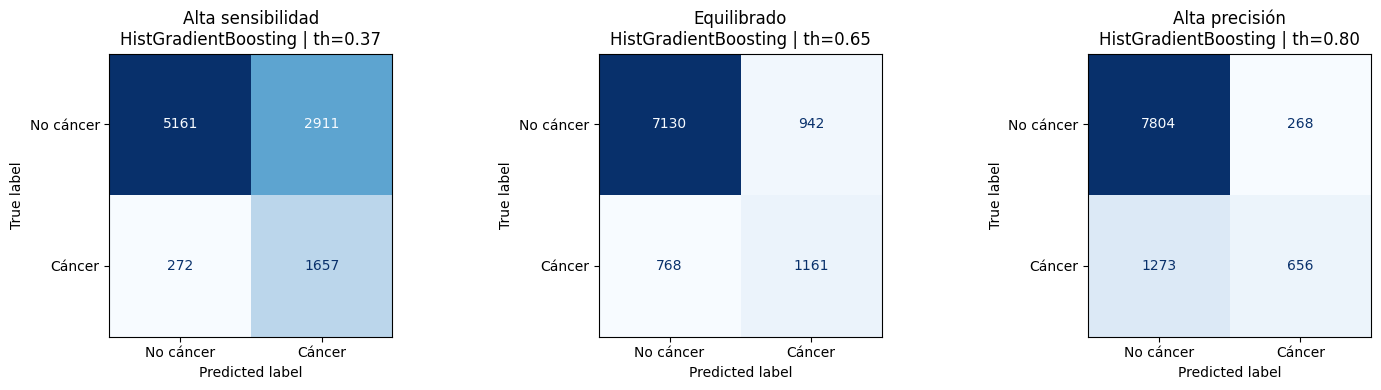

,escenario,objetivo,threshold,TP,FP,FN,TN,precision,recall,f1
0,Alta sensibilidad,Objetivo: recall >= 0.85,0.37,1657,2911,272,5161,0.363,0.859,0.510
1,Equilibrado,Objetivo: máximo F1,0.65,1161,942,768,7130,0.552,0.602,0.576
2,Alta precisión,Objetivo: precision >= 0.70,0.80,656,268,1273,7804,0.710,0.340,0.460


In [25]:
# 1. Umbral como política de decisión
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay


# Comprobaciones de dependencias del bloque.
# Este bloque necesita que se hayan ejecutado Fase 4 y Fase 5, pero reconstruye
# objetos derivados si existen las probabilidades/validación necesarias.
if "y_test_proba_operativo" not in globals() or "threshold_results_operativo" not in globals():
    raise RuntimeError("Faltan variables del modelo operativo. Ejecuta el setup rápido o `modelo.ipynb` hasta la Fase 7.")

# Se eligen umbrales usando validación, no test.
politicas = []

# 1) Alta sensibilidad: recall >= 0.85, eligiendo la mayor precisión posible entre esos umbrales.
candidatos_recall = threshold_results_operativo[threshold_results_operativo["recall"] >= 0.85].copy()
if len(candidatos_recall) > 0:
    fila_alta_sensibilidad = candidatos_recall.sort_values(["precision", "f1"], ascending=False).iloc[0]
else:
    fila_alta_sensibilidad = threshold_results_operativo.sort_values("recall", ascending=False).iloc[0]

# 2) Equilibrado: máximo F1.
fila_equilibrada = threshold_results_operativo.sort_values("f1", ascending=False).iloc[0]

# 3) Alta precisión: precision >= 0.70, eligiendo el mayor recall posible entre esos umbrales.
candidatos_precision = threshold_results_operativo[threshold_results_operativo["precision"] >= 0.70].copy()
if len(candidatos_precision) > 0:
    fila_alta_precision = candidatos_precision.sort_values(["recall", "f1"], ascending=False).iloc[0]
else:
    fila_alta_precision = threshold_results_operativo.sort_values("precision", ascending=False).iloc[0]

escenarios = [
    ("Alta sensibilidad", fila_alta_sensibilidad, "Objetivo: recall >= 0.85"),
    ("Equilibrado", fila_equilibrada, "Objetivo: máximo F1"),
    ("Alta precisión", fila_alta_precision, "Objetivo: precision >= 0.70"),
]

filas_politicas = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, fila, objetivo) in zip(axes, escenarios):
    threshold = float(fila["threshold"])
    y_pred = (y_test_proba_operativo >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    filas_politicas.append(
        {
            "escenario": nombre,
            "objetivo": objetivo,
            "threshold": threshold,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        }
    )
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["No cáncer", "Cáncer"],
    ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(f"{nombre}\n{modelo_operativo_nombre} | th={threshold:.2f}")

politicas_umbral = pd.DataFrame(filas_politicas)
plt.tight_layout()
fig.savefig(FIG_DIR / "01_politicas_umbral_matrices_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

display(
    politicas_umbral.style.format(
        {"threshold": "{:.2f}", "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}
    )
)


### Interpretación clínica

El modelo es el mismo, pero cambia la política de decisión. Un umbral bajo prioriza detectar más casos, aunque aumenten las falsas alarmas. Un umbral alto prioriza precisión, pero puede dejar más pacientes con cáncer sin alerta. La elección del umbral debe depender del uso clínico previsto.


## 2. Incertidumbre estadística: intervalos de confianza

Las métricas puntuales no bastan para tomar decisiones. Se usa bootstrap sobre test para estimar intervalos de confianza del 95% en AUC, F1, recall y precisión.


In [26]:
# 2. Bootstrap de métricas en test
from sklearn.metrics import roc_auc_score

N_BOOTSTRAP = 1000
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_metricas(nombre, y_true, y_proba, threshold, n_bootstrap=N_BOOTSTRAP):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    filas = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        y_pred = (y_proba[idx] >= threshold).astype(int)
        filas.append(
            {
                "modelo": nombre,
                "auc_roc": roc_auc_score(y_true[idx], y_proba[idx]),
                "f1": f1_score(y_true[idx], y_pred, zero_division=0),
                "recall": recall_score(y_true[idx], y_pred, zero_division=0),
                "precision": precision_score(y_true[idx], y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(filas)

boot_ml = bootstrap_metricas(mejor_modelo_ml_nombre, y_test, y_test_proba_ml, threshold_ml)
boot_mlp = bootstrap_metricas("MLP", y_test, y_test_proba_mlp, best_threshold_mlp)
bootstrap_resultados = pd.concat([boot_ml, boot_mlp], ignore_index=True)

filas_ci = []
for modelo, df_modelo in bootstrap_resultados.groupby("modelo"):
    for metrica in ["auc_roc", "f1", "recall", "precision"]:
        valores = df_modelo[metrica].dropna().to_numpy()
        filas_ci.append(
            {
                "modelo": modelo,
                "metrica": metrica,
                "media": valores.mean(),
                "ci_95_inf": np.percentile(valores, 2.5),
                "ci_95_sup": np.percentile(valores, 97.5),
            }
        )

bootstrap_ci = pd.DataFrame(filas_ci)
display(bootstrap_ci.style.format({"media": "{:.3f}", "ci_95_inf": "{:.3f}", "ci_95_sup": "{:.3f}"}))


,modelo,metrica,media,ci_95_inf,ci_95_sup
0,HistGradientBoosting,auc_roc,0.843,0.833,0.852
1,HistGradientBoosting,f1,0.575,0.558,0.594
2,HistGradientBoosting,recall,0.602,0.579,0.623
3,HistGradientBoosting,precision,0.552,0.531,0.573
4,MLP,auc_roc,0.840,0.830,0.849
5,MLP,f1,0.572,0.555,0.589
6,MLP,recall,0.631,0.609,0.652
7,MLP,precision,0.523,0.503,0.544


### Interpretación clínica

Los intervalos de confianza permiten valorar si las diferencias entre modelos son sólidas. Si los intervalos se solapan mucho, no conviene afirmar superioridad clara sin validación adicional.


## 3. Calibración de probabilidades

En clínica no solo importa ordenar bien a los pacientes. También importa que una probabilidad estimada sea interpretable: si el modelo predice 30%, esa cifra debería aproximarse al riesgo real observado.

Como la MLP mostraba mejor Brier score que `HistGradientBoosting`, se añade una versión calibrada del Boosting. La calibración se ajusta solo con datos de train mediante validación cruzada interna; el test sigue reservado para evaluar el resultado final.


,modelo,brier_score,auc_roc
1,HistGradientBoosting calibrado,0.1102,0.844
2,MLP,0.1113,0.840
0,HistGradientBoosting,0.1563,0.843


,modelo,threshold,precision_cancer_1,recall_cancer_1,f1_cancer_1,auc_roc,accuracy
0,HistGradientBoosting calibrado,0.29,0.512,0.664,0.578,0.844,0.813


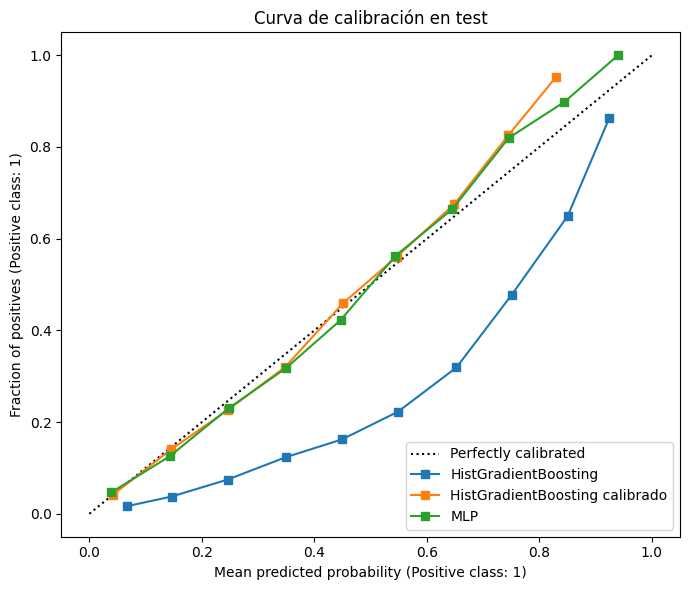

In [27]:
# 3. Calibración de probabilidades
from pathlib import Path

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def metricas_probabilidad(nombre, y_true, y_proba):
    return {
        "modelo": nombre,
        "brier_score": brier_score_loss(y_true, y_proba),
        "auc_roc": roc_auc_score(y_true, y_proba),
    }


# Calibración del Boosting usando solo train.
boosting_calibrado = CalibratedClassifierCV(
    estimator=clone(mejor_modelo_ml),
    method="sigmoid",
    cv=5,
    n_jobs=1,
)
boosting_calibrado.fit(X_train_prep, y_train)
y_test_proba_ml_calibrado = boosting_calibrado.predict_proba(X_test_prep)[:, 1]

# El umbral del modelo calibrado se ajusta en la validación interna, no en test.
boosting_calibrado_para_umbral = CalibratedClassifierCV(
    estimator=clone(mejor_modelo_ml),
    method="sigmoid",
    cv=3,
    n_jobs=1,
)
boosting_calibrado_para_umbral.fit(X_mlp_train, y_mlp_train.astype(int))
y_val_proba_ml_calibrado = boosting_calibrado_para_umbral.predict_proba(X_mlp_val)[:, 1]

threshold_results_ml_calibrado = pd.DataFrame(
    [
        {
            "threshold": threshold,
            "precision": precision_score(
                y_mlp_val.astype(int),
                y_val_proba_ml_calibrado >= threshold,
                zero_division=0,
            ),
            "recall": recall_score(
                y_mlp_val.astype(int),
                y_val_proba_ml_calibrado >= threshold,
                zero_division=0,
            ),
            "f1": f1_score(
                y_mlp_val.astype(int),
                y_val_proba_ml_calibrado >= threshold,
                zero_division=0,
            ),
        }
        for threshold in thresholds
    ]
)
best_threshold_ml_calibrado = float(
    threshold_results_ml_calibrado.sort_values("f1", ascending=False).iloc[0]["threshold"]
)

calibracion_brier = pd.DataFrame(
    [
        metricas_probabilidad(mejor_modelo_ml_nombre, y_test, y_test_proba_ml),
        metricas_probabilidad(f"{mejor_modelo_ml_nombre} calibrado", y_test, y_test_proba_ml_calibrado),
        metricas_probabilidad("MLP", y_test, y_test_proba_mlp),
    ]
).sort_values("brier_score")

display(calibracion_brier.style.format({"brier_score": "{:.4f}", "auc_roc": "{:.3f}"}))

metricas_calibrado = pd.DataFrame(
    [
        calcular_metricas(
            f"{mejor_modelo_ml_nombre} calibrado",
            y_test,
            y_test_proba_ml_calibrado,
            best_threshold_ml_calibrado,
        )
    ]
)
display(
    metricas_calibrado.style.format(
        {
            "threshold": "{:.2f}",
            "precision_cancer_1": "{:.3f}",
            "recall_cancer_1": "{:.3f}",
            "f1_cancer_1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_test, y_test_proba_ml, n_bins=10, name=mejor_modelo_ml_nombre, ax=ax)
CalibrationDisplay.from_predictions(
    y_test,
    y_test_proba_ml_calibrado,
    n_bins=10,
    name=f"{mejor_modelo_ml_nombre} calibrado",
    ax=ax,
)
CalibrationDisplay.from_predictions(y_test, y_test_proba_mlp, n_bins=10, name="MLP", ax=ax)
ax.set_title("Curva de calibración en test")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_curva_calibracion.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación clínica

La calibración separa dos objetivos que a veces se mezclan: ordenar pacientes y asignar probabilidades interpretables. Una buena AUC indica buena capacidad de ranking, pero no garantiza que una probabilidad estimada como 30% corresponda a un riesgo observado cercano al 30%.

Con `CalibratedClassifierCV`, el Boosting calibrado corrige el problema principal: reduce el Brier score y mantiene un rendimiento discriminativo similar. Por tanto, si el sistema va a mostrar una probabilidad de riesgo, la versión calibrada del Boosting es más defendible que las probabilidades crudas del modelo original.

La calibración no sustituye la decisión clínica sobre el umbral. Después de calibrar, el umbral óptimo puede cambiar porque la escala de probabilidades cambia. Por eso se vuelve a elegir el threshold en validación y se evalúa en test.


## 4. Robustez y generalización interna

Un único split puede no representar toda la variabilidad del dataset. Se evalúa el mejor baseline con validación cruzada estratificada en train, manteniendo test reservado para la evaluación final.

Para no infravalorar artificialmente el modelo operativo, se reportan métricas con dos políticas:

- `threshold = 0.50`, referencia estándar.
- `threshold_operativo`, el umbral elegido en validación para la decisión final.


In [28]:
# 4. Validación cruzada estratificada en train
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

cv_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.06,
    l2_regularization=0.1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas_cv = []

for fold, (idx_train_cv, idx_val_cv) in enumerate(cv.split(X_train, y_train), start=1):
    X_train_cv = X_train.iloc[idx_train_cv]
    X_val_cv = X_train.iloc[idx_val_cv]
    y_train_cv = y_train.iloc[idx_train_cv]
    y_val_cv = y_train.iloc[idx_val_cv]

    cv_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(cv_model)),
        ]
    )
    cv_pipeline.fit(X_train_cv, y_train_cv)
    y_val_proba_cv = cv_pipeline.predict_proba(X_val_cv)[:, 1]

    for politica, threshold in [
        ("threshold_0.50", 0.50),
        ("threshold_operativo", threshold_operativo),
    ]:
        y_val_pred_cv = (y_val_proba_cv >= threshold).astype(int)
        filas_cv.append(
            {
                "fold": fold,
                "politica": politica,
                "threshold": threshold,
                "auc_roc": roc_auc_score(y_val_cv, y_val_proba_cv),
                "f1": f1_score(y_val_cv, y_val_pred_cv, zero_division=0),
                "recall": recall_score(y_val_cv, y_val_pred_cv, zero_division=0),
                "precision": precision_score(y_val_cv, y_val_pred_cv, zero_division=0),
            }
        )

cv_resultados = pd.DataFrame(filas_cv)
cv_resumen = (
    cv_resultados.groupby("politica")
    .agg(
        threshold=("threshold", "first"),
        auc_roc_media=("auc_roc", "mean"),
        auc_roc_std=("auc_roc", "std"),
        f1_media=("f1", "mean"),
        f1_std=("f1", "std"),
        recall_media=("recall", "mean"),
        recall_std=("recall", "std"),
        precision_media=("precision", "mean"),
        precision_std=("precision", "std"),
    )
    .reset_index()
)

display(
    cv_resumen.style.format(
        {
            "threshold": "{:.2f}",
            "auc_roc_media": "{:.3f}",
            "auc_roc_std": "{:.3f}",
            "f1_media": "{:.3f}",
            "f1_std": "{:.3f}",
            "recall_media": "{:.3f}",
            "recall_std": "{:.3f}",
            "precision_media": "{:.3f}",
            "precision_std": "{:.3f}",
        }
    )
)


,politica,threshold,auc_roc_media,auc_roc_std,f1_media,f1_std,recall_media,recall_std,precision_media,precision_std
0,threshold_0.50,0.50,0.839,0.005,0.548,0.008,0.748,0.013,0.432,0.010
1,threshold_operativo,0.65,0.839,0.005,0.561,0.007,0.585,0.016,0.540,0.013


### Interpretación clínica

La validación cruzada evalúa estabilidad frente a cambios de partición. El AUC no depende del umbral y sirve para medir capacidad de ordenación. El F1, recall y precisión sí dependen de la política de decisión, por eso se muestran tanto con `0.50` como con el umbral operativo.

El umbral operativo mejora el F1 medio respecto a `0.50`, aunque reduce recall y aumenta precisión. Esto confirma que ajustar el punto de corte era necesario y que la métrica final de test no debe compararse directamente con una CV calculada solo con el umbral estándar.


## 5. Interpretabilidad global y local

La interpretabilidad ayuda a revisar si el modelo usa señales clínicamente plausibles. Se usa SHAP en modo rápido para obtener una explicación global y un ejemplo local sin bloquear el notebook.


Modelo usado para SHAP: Extra Trees
Muestra explicada: 200 pacientes


,feature,mean_abs_shap
20,num__fumador,0.0996
9,num__obesidad,0.0795
14,num__mut_TP53,0.0582
13,num__mut_BRCA1,0.0460
16,num__mut_KRAS,0.0452
26,cat__tipo_seguro_Privado,0.0399
27,cat__tipo_seguro_Publico,0.0389
29,cat__actividad_fisica_Baja,0.0336
8,num__hipertension,0.0307
15,num__mut_EGFR,0.0218


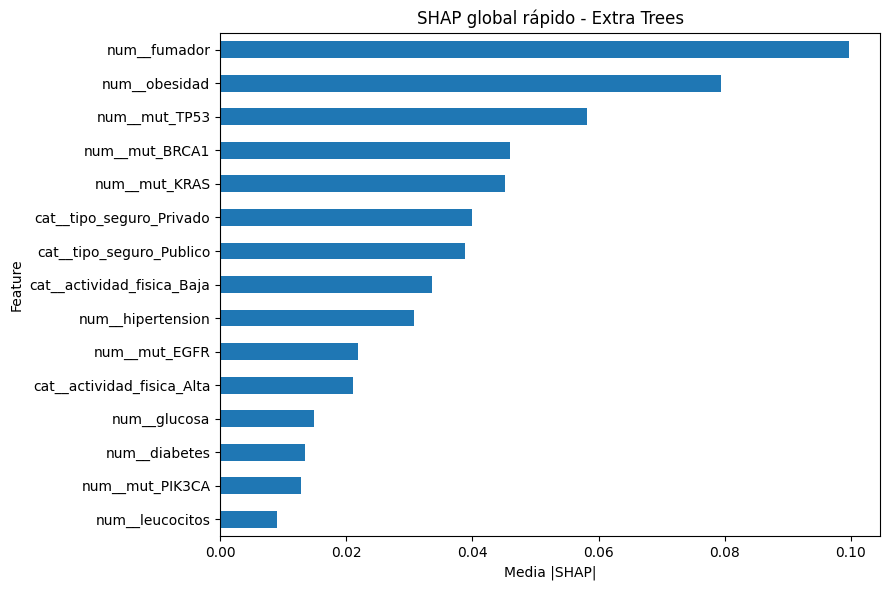

Ejemplo local explicado | y real=1


,feature,valor,shap_value,abs_shap
14,num__mut_TP53,2.698,0.2346,0.2346
20,num__fumador,-0.783,-0.1009,0.1009
26,cat__tipo_seguro_Privado,1.000,0.0750,0.0750
9,num__obesidad,-0.740,-0.0692,0.0692
27,cat__tipo_seguro_Publico,0.000,0.0464,0.0464
13,num__mut_BRCA1,-0.298,-0.0326,0.0326
8,num__hipertension,-0.888,-0.0324,0.0324
16,num__mut_KRAS,-0.386,-0.0282,0.0282
29,cat__actividad_fisica_Baja,1.000,0.0271,0.0271
22,num__edad,-1.181,-0.0218,0.0218


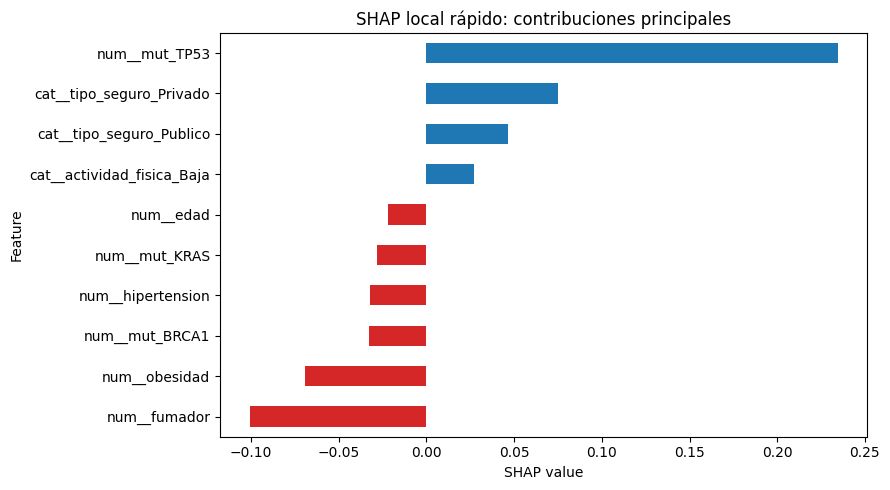

In [29]:
# 5. SHAP global y local en modo rápido
import shap
from pathlib import Path

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Modelo de árboles usado para interpretación. Normalmente Extra Trees.
modelo_shap_nombre = modelo_importancia_nombre if "modelo_importancia_nombre" in globals() else mejor_modelo_ml_nombre
modelo_shap = modelo_importancia if "modelo_importancia" in globals() else mejor_modelo_ml

# Muestra pequeña para que SHAP no bloquee el notebook.
SHAP_SAMPLE_SIZE = 200
rng = np.random.default_rng(RANDOM_STATE)
sample_size_shap = min(SHAP_SAMPLE_SIZE, X_test_prep.shape[0])
sample_idx_shap = rng.choice(X_test_prep.shape[0], size=sample_size_shap, replace=False)
X_shap = pd.DataFrame(X_test_prep[sample_idx_shap], columns=feature_names)

explainer_shap = shap.TreeExplainer(modelo_shap)
shap_values_raw = explainer_shap.shap_values(X_shap)

# En clasificación binaria algunos explainers devuelven lista por clase o array 3D.
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw
    if getattr(shap_values, "ndim", 2) == 3:
        shap_values = shap_values[:, :, 1]

print(f"Modelo usado para SHAP: {modelo_shap_nombre}")
print(f"Muestra explicada: {sample_size_shap} pacientes")

# Importancia global rápida: media del valor absoluto SHAP.
shap_global = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

display(shap_global.style.format({"mean_abs_shap": "{:.4f}"}))

ax = shap_global.sort_values("mean_abs_shap").plot.barh(
    x="feature",
    y="mean_abs_shap",
    figsize=(9, 6),
    legend=False,
)
ax.set_title(f"SHAP global rápido - {modelo_shap_nombre}")
ax.set_xlabel("Media |SHAP|")
ax.set_ylabel("Feature")
plt.tight_layout()
ax.figure.savefig(FIG_DIR / "05_shap_global.png", dpi=300, bbox_inches="tight")
plt.show()

# Ejemplo local: primer paciente positivo de la muestra; si no hay, el primero disponible.
y_shap_true = y_test.iloc[sample_idx_shap].to_numpy()
positivos = np.where(y_shap_true == 1)[0]
idx_local = int(positivos[0]) if len(positivos) > 0 else 0

shap_local = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "valor": X_shap.iloc[idx_local].to_numpy(),
            "shap_value": shap_values[idx_local],
            "abs_shap": np.abs(shap_values[idx_local]),
        }
    )
    .sort_values("abs_shap", ascending=False)
    .head(10)
)

print(f"Ejemplo local explicado | y real={int(y_shap_true[idx_local])}")
display(shap_local.style.format({"valor": "{:.3f}", "shap_value": "{:.4f}", "abs_shap": "{:.4f}"}))

ax = shap_local.sort_values("shap_value").plot.barh(
    x="feature",
    y="shap_value",
    figsize=(9, 5),
    legend=False,
    color=["#1f77b4" if v >= 0 else "#d62728" for v in shap_local.sort_values("shap_value")["shap_value"]],
)
ax.set_title("SHAP local rápido: contribuciones principales")
ax.set_xlabel("SHAP value")
ax.set_ylabel("Feature")
plt.tight_layout()
ax.figure.savefig(FIG_DIR / "05_shap_local.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación clínica

La explicación global indica qué variables influyen más en promedio. La explicación local muestra por qué un paciente concreto recibe una alerta o no. Esto mejora la trazabilidad, pero no convierte las asociaciones en causalidad.


## 6. Auditoría de sesgo por subgrupos

Antes de plantear uso clínico, se revisa si el rendimiento del modelo operativo (`HistGradientBoosting` con umbral optimizado) cambia entre grupos socioeconómicos o geográficos disponibles en los datos.


,variable_subgrupo,grupo,n,prevalencia,precision,recall
0,nivel_educativo,Primaria,2523,0.199,0.540,0.574
3,nivel_educativo,Universitario,2488,0.196,0.565,0.595
1,nivel_educativo,Secundaria,3973,0.191,0.543,0.610
2,nivel_educativo,Sin estudios,1017,0.178,0.585,0.663
5,zona,Semiurbana,2569,0.180,0.512,0.598
6,zona,Urbana,5432,0.195,0.556,0.599
4,zona,Rural,2000,0.204,0.593,0.614


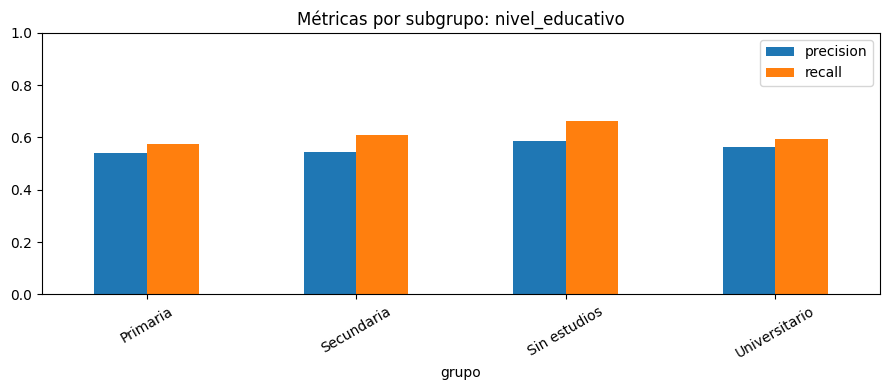

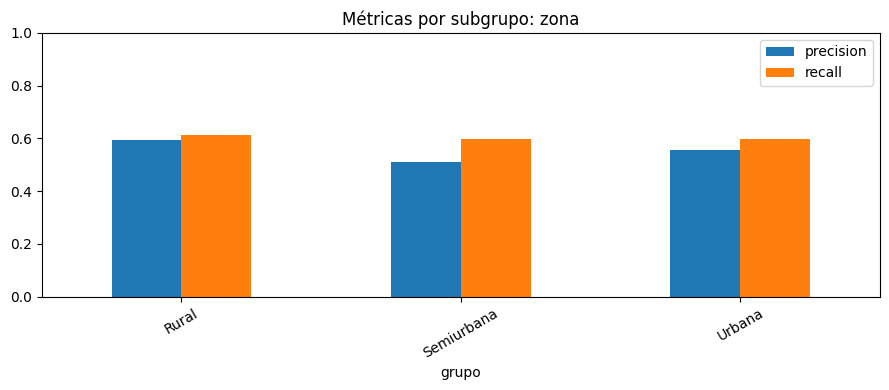

In [30]:
# 6. Auditoría de sesgo por subgrupos
from pathlib import Path

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

subgrupos_candidatos = ["nivel_educativo", "zona", "sexo"]
subgrupos_disponibles = [col for col in subgrupos_candidatos if col in X_test.columns]

filas_bias = []
y_pred_auditoria = y_test_pred_operativo

for col in subgrupos_disponibles:
    for valor, indices in X_test.groupby(col).groups.items():
        idx = list(indices)
        y_true_g = y_test.loc[idx]
        # y_test_pred_operativo está en el orden posicional de X_test; mapeamos posiciones.
        pos = X_test.index.get_indexer(idx)
        y_pred_g = y_pred_auditoria[pos]
        if len(y_true_g) < 30:
            continue
        filas_bias.append(
            {
                "variable_subgrupo": col,
                "grupo": valor,
                "n": len(y_true_g),
                "prevalencia": y_true_g.mean(),
                "precision": precision_score(y_true_g, y_pred_g, zero_division=0),
                "recall": recall_score(y_true_g, y_pred_g, zero_division=0),
            }
        )

auditoria_sesgo = pd.DataFrame(filas_bias)
display(auditoria_sesgo.sort_values(["variable_subgrupo", "recall"]).style.format({"prevalencia": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}"}))

if not auditoria_sesgo.empty:
    for col in subgrupos_disponibles:
        df_col = auditoria_sesgo[auditoria_sesgo["variable_subgrupo"] == col].copy()
        if df_col.empty:
            continue
        ax = df_col.set_index("grupo")[["precision", "recall"]].plot(kind="bar", figsize=(9, 4), rot=30)
        ax.set_title(f"Métricas por subgrupo: {col}")
        ax.set_ylim(0, 1)
        plt.tight_layout()
        ax.figure.savefig(FIG_DIR / f"06_auditoria_sesgo_{col}.png", dpi=300, bbox_inches="tight")
        plt.show()


### Interpretación clínica

Diferencias grandes de recall o precisión entre subgrupos pueden indicar desigualdad de rendimiento. No prueban discriminación por sí solas, pero obligan a revisar el modelo antes de desplegarlo.


## 7. Validación explícita de fuga de datos

Se compara un modelo con variables post-diagnóstico frente al modelo limpio. Este bloque documenta de forma empírica cuánto inflaba el leakage el rendimiento.

Para evitar confusión con la evaluación final, se informa el `threshold` usado. En el escenario sin leakage se usa el umbral operativo optimizado en validación (`threshold_operativo`). El escenario con variables post-diagnóstico usa el mismo umbral para que la comparación no mezcle el efecto del leakage con un cambio de política de decisión.


In [31]:
# 7. Comparación con y sin variables de leakage
from sklearn.pipeline import Pipeline

threshold_leakage_comparacion = float(threshold_operativo)


def entrenar_hgb_con_columnas(columnas_excluidas, etiqueta, threshold):
    X_leak = df_cancer.drop(columns=columnas_excluidas)
    y_leak = df_cancer[TARGET].astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_leak, y_leak, test_size=0.20, random_state=RANDOM_STATE, stratify=y_leak
    )
    num_cols = X_tr.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    prep = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ]
    )
    pipe = Pipeline(
        steps=[
            (
                "preprocessor",
                prep,
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=300,
                    learning_rate=0.06,
                    l2_regularization=0.1,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    pipe.fit(X_tr, y_tr)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "escenario": etiqueta,
        "n_features": X_leak.shape[1],
        "threshold": threshold,
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_te, y_proba),
        "accuracy": accuracy_score(y_te, y_pred),
    }


resultado_sin_leakage = entrenar_hgb_con_columnas(
    [TARGET, ID_COL] + leakage_or_postdiagnosis_features,
    "Sin leakage",
    threshold_leakage_comparacion,
)
resultado_con_leakage = entrenar_hgb_con_columnas(
    [TARGET, ID_COL],
    "Con variables post-diagnóstico",
    threshold_leakage_comparacion,
)

comparacion_leakage = pd.DataFrame([resultado_sin_leakage, resultado_con_leakage])
display(
    comparacion_leakage.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)


,escenario,n_features,threshold,precision,recall,f1,auc_roc,accuracy
0,Sin leakage,31,0.65,0.552,0.602,0.576,0.843,0.829
1,Con variables post-diagnóstico,36,0.65,0.990,0.970,0.980,0.999,0.993


### Interpretación clínica

Si las métricas suben mucho al incluir variables post-diagnóstico, el modelo contaminado no es válido para cribado. Esta comparación justifica excluir dichas variables y refuerza la credibilidad del análisis.

La columna `threshold` evita mezclar dos discusiones distintas: el efecto de la fuga de datos y la elección del punto de corte. Incluso usando la misma política de decisión que el modelo operativo, las variables post-diagnóstico producen métricas artificialmente altas.


## 8. Recomendación operativa

Se traduce el modelo operativo a un flujo realista: probabilidad de riesgo, alerta y revisión o prueba confirmatoria. El modelo no diagnostica; prioriza pacientes. Tras la comparación con umbrales optimizados, el flujo operativo se basa en `HistGradientBoosting`.

Si la salida se comunica como probabilidad de riesgo, conviene usar la versión calibrada del Boosting. Si la salida se comunica solo como alerta/no alerta, basta con usar el umbral operativo validado.


In [32]:
# 8. Simulación operativa por cada 1.000 pacientes
politica_operativa = politicas_umbral.loc[politicas_umbral["escenario"] == "Equilibrado"].iloc[0]

escala = 1000 / len(y_test)
simulacion_1000 = pd.DataFrame(
    [
        {
            "politica": politica_operativa["escenario"],
            "threshold": politica_operativa["threshold"],
            "alertas_totales": (politica_operativa["TP"] + politica_operativa["FP"]) * escala,
            "positivos_detectados_TP": politica_operativa["TP"] * escala,
            "falsos_positivos_FP": politica_operativa["FP"] * escala,
            "falsos_negativos_FN": politica_operativa["FN"] * escala,
        }
    ]
)

display(simulacion_1000.style.format({"threshold": "{:.2f}", "alertas_totales": "{:.1f}", "positivos_detectados_TP": "{:.1f}", "falsos_positivos_FP": "{:.1f}", "falsos_negativos_FN": "{:.1f}"}))


,politica,threshold,alertas_totales,positivos_detectados_TP,falsos_positivos_FP,falsos_negativos_FN
0,Equilibrado,0.65,210.3,116.1,94.2,76.8


### Interpretación clínica

La simulación por 1.000 pacientes permite estimar carga asistencial: cuántas alertas se generan, cuántos casos se detectarían y cuántos falsos positivos habría que gestionar.


## 9. Análisis coste-beneficio del umbral

La decisión óptima depende del coste relativo de los errores. En cribado, un falso negativo suele pesar más que un falso positivo, por lo que se analiza el coste esperado para distintos thresholds del modelo operativo.


,threshold,TP,FP,FN,TN,coste_total,coste_por_1000
17,0.27,1769.000000,3815.000000,160.000000,4257.000000,5415.000000,541.4


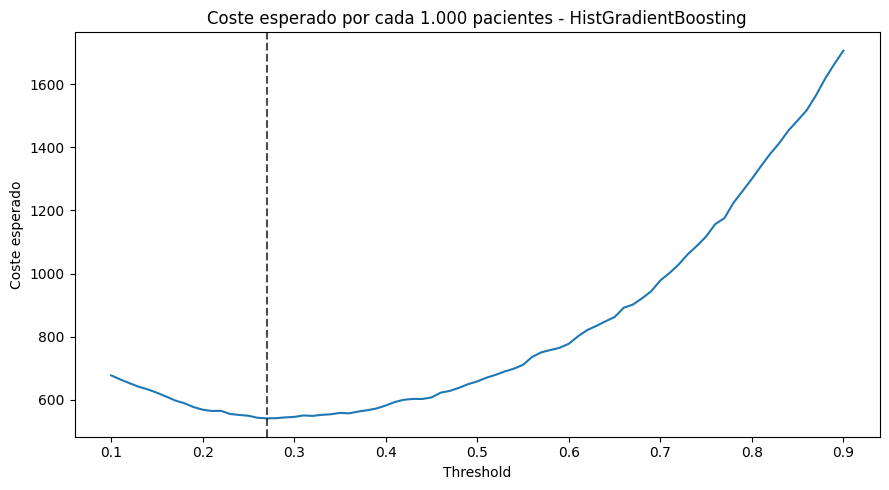

In [33]:
# 9. Coste esperado por threshold
from pathlib import Path

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

coste_FN = 10
coste_FP = 1

filas_coste = []
for threshold in thresholds:
    y_pred = (y_test_proba_operativo >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    coste_total = coste_FN * fn + coste_FP * fp
    filas_coste.append(
        {
            "threshold": threshold,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "coste_total": coste_total,
            "coste_por_1000": coste_total * (1000 / len(y_test)),
        }
    )

coste_threshold = pd.DataFrame(filas_coste)
fila_coste_optimo = coste_threshold.sort_values("coste_total").iloc[0]
threshold_coste_optimo = float(fila_coste_optimo["threshold"])

display(fila_coste_optimo.to_frame().T.style.format({"threshold": "{:.2f}", "coste_por_1000": "{:.1f}"}))

ax = coste_threshold.plot(x="threshold", y="coste_por_1000", figsize=(9, 5), legend=False)
ax.axvline(threshold_coste_optimo, color="black", linestyle="--", alpha=0.7)
ax.set_title(f"Coste esperado por cada 1.000 pacientes - {modelo_operativo_nombre}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Coste esperado")
plt.tight_layout()
ax.figure.savefig(FIG_DIR / "09_curva_coste_beneficio.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación clínica

El mejor threshold depende del coste clínico. Si el falso negativo pesa 10 veces más que el falso positivo, el umbral óptimo puede ser más bajo que el de máximo F1, porque interesa capturar más casos aunque aumenten las alertas.


## 10. Ficha operativa del sistema

Se resume la política de uso del `HistGradientBoosting calibrado`: alerta de riesgo para priorizar revisión clínica o prueba confirmatoria, no diagnóstico automático.


In [34]:
# 10. Policy card / ficha operativa del sistema
from pathlib import Path

from sklearn.metrics import confusion_matrix

FIG_DIR = Path("figures/evaluacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# La ficha operativa se construye sobre el modelo calibrado, porque es el
# candidato recomendado cuando se informa riesgo probabilístico.
def construir_politicas_operativas(y_true, y_proba, thresholds):
    filas = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        filas.append(
            {
                "threshold": float(threshold),
                "TP": int(tp),
                "FP": int(fp),
                "FN": int(fn),
                "TN": int(tn),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    tabla = pd.DataFrame(filas)

    cribado = tabla[tabla["recall"] >= 0.85].sort_values("threshold", ascending=False).head(1)
    if cribado.empty:
        cribado = tabla.sort_values("recall", ascending=False).head(1)

    equilibrado = tabla.sort_values("f1", ascending=False).head(1)

    alta_precision = tabla[tabla["precision"] >= 0.70].sort_values("threshold").head(1)
    if alta_precision.empty:
        alta_precision = tabla.sort_values("precision", ascending=False).head(1)

    politicas = pd.concat(
        [
            cribado.assign(escenario="Cribado", objetivo="Recall >= 0.85"),
            equilibrado.assign(escenario="Equilibrado", objetivo="Máximo F1"),
            alta_precision.assign(escenario="Alta precisión", objetivo="Precisión >= 0.70"),
        ],
        ignore_index=True,
    )
    return politicas[
        [
            "escenario",
            "objetivo",
            "threshold",
            "TP",
            "FP",
            "FN",
            "TN",
            "precision",
            "recall",
            "f1",
        ]
    ]

politicas_card = construir_politicas_operativas(y_test, y_test_proba_ml_calibrado, thresholds)
politicas_card["modelo"] = f"{mejor_modelo_ml_nombre} calibrado"
politicas_card["uso"] = "alerta -> prueba confirmatoria"
politicas_card["riesgos"] = "falsos positivos; sesgo; dependencia de prevalencia"

policy_card = politicas_card[
    [
        "modelo",
        "escenario",
        "objetivo",
        "threshold",
        "precision",
        "recall",
        "f1",
        "TP",
        "FP",
        "FN",
        "TN",
        "uso",
        "riesgos",
    ]
].copy()

escala = 1000 / len(y_test)
policy_card["detectados_por_1000"] = policy_card["TP"] * escala
policy_card["falsos_positivos_por_1000"] = policy_card["FP"] * escala
policy_card["falsos_negativos_por_1000"] = policy_card["FN"] * escala

policy_card = policy_card[
    [
        "modelo",
        "escenario",
        "threshold",
        "precision",
        "recall",
        "f1",
        "detectados_por_1000",
        "falsos_positivos_por_1000",
        "falsos_negativos_por_1000",
        "uso",
        "riesgos",
    ]
]

display(
    policy_card.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "detectados_por_1000": "{:.1f}",
            "falsos_positivos_por_1000": "{:.1f}",
            "falsos_negativos_por_1000": "{:.1f}",
        }
    )
)


,modelo,escenario,threshold,precision,recall,f1,detectados_por_1000,falsos_positivos_por_1000,falsos_negativos_por_1000,uso,riesgos
0,HistGradientBoosting calibrado,Cribado,0.13,0.363,0.857,0.510,165.3,290.3,27.6,alerta -> prueba confirmatoria,falsos positivos; sesgo; dependencia de prevalencia
1,HistGradientBoosting calibrado,Equilibrado,0.34,0.557,0.605,0.580,116.8,92.8,76.1,alerta -> prueba confirmatoria,falsos positivos; sesgo; dependencia de prevalencia
2,HistGradientBoosting calibrado,Alta precisión,0.52,0.700,0.363,0.478,70.1,30.0,122.8,alerta -> prueba confirmatoria,falsos positivos; sesgo; dependencia de prevalencia


### Interpretación

El umbral de cribado (`0.13`) prioriza recall y reduce falsos negativos, pero aumenta mucho las alertas. El umbral equilibrado (`0.34`) mantiene el mejor balance global y queda como política general recomendada. La salida siempre debe terminar en revisión clínica o prueba confirmatoria.


## 11. Error analysis: falsos negativos

Se analizan los falsos negativos porque son el error clínicamente más importante: casos con `cancer = 1` que no reciben alerta. Se comparan contra los verdaderos positivos para ver qué perfiles se escapan.


In [35]:
# 11. Error analysis centrado en falsos negativos
import numpy as np
import pandas as pd

if "y_test_pred_operativo" not in globals():
    y_test_pred_operativo = (y_test_proba_operativo >= threshold_operativo).astype(int)

y_true_test = y_test.to_numpy().astype(int)
y_pred_test = np.asarray(y_test_pred_operativo).astype(int)

mask_tp = (y_true_test == 1) & (y_pred_test == 1)
mask_fn = (y_true_test == 1) & (y_pred_test == 0)

X_test_reset = X_test.reset_index(drop=True)

numeric_error_cols = X_test_reset.select_dtypes(include=["number", "bool"]).columns.tolist()
error_rows = []
for col in numeric_error_cols:
    tp_values = X_test_reset.loc[mask_tp, col]
    fn_values = X_test_reset.loc[mask_fn, col]
    error_rows.append(
        {
            "variable": col,
            "media_TP": tp_values.mean(),
            "media_FN": fn_values.mean(),
            "delta_FN_menos_TP": fn_values.mean() - tp_values.mean(),
            "abs_delta": abs(fn_values.mean() - tp_values.mean()),
        }
    )

error_numeric = pd.DataFrame(error_rows).sort_values("abs_delta", ascending=False)

display(
    error_numeric.head(15).style.format(
        {
            "media_TP": "{:.3f}",
            "media_FN": "{:.3f}",
            "delta_FN_menos_TP": "{:+.3f}",
            "abs_delta": "{:.3f}",
        }
    )
)

categorical_error_cols = [
    col for col in ["actividad_fisica", "nivel_educativo", "zona", "tipo_seguro", "estado_civil"]
    if col in X_test_reset.columns
]
cat_rows = []
for col in categorical_error_cols:
    dist_tp = X_test_reset.loc[mask_tp, col].value_counts(normalize=True)
    dist_fn = X_test_reset.loc[mask_fn, col].value_counts(normalize=True)
    for value in sorted(set(dist_tp.index).union(set(dist_fn.index))):
        cat_rows.append(
            {
                "variable": col,
                "categoria": value,
                "prop_TP": dist_tp.get(value, 0.0),
                "prop_FN": dist_fn.get(value, 0.0),
                "delta_FN_menos_TP": dist_fn.get(value, 0.0) - dist_tp.get(value, 0.0),
            }
        )

error_categorico = pd.DataFrame(cat_rows)
if not error_categorico.empty:
    error_categorico["abs_delta"] = error_categorico["delta_FN_menos_TP"].abs()
    display(
        error_categorico.sort_values("abs_delta", ascending=False)
        .head(12)
        .style.format(
            {
                "prop_TP": "{:.3f}",
                "prop_FN": "{:.3f}",
                "delta_FN_menos_TP": "{:+.3f}",
                "abs_delta": "{:.3f}",
            }
        )
    )

print(f"TP analizados: {int(mask_tp.sum())}")
print(f"FN analizados: {int(mask_fn.sum())}")
print("Variables numéricas con mayor diferencia FN vs TP:")
for _, row in error_numeric.head(5).iterrows():
    direccion = "mayor" if row["delta_FN_menos_TP"] > 0 else "menor"
    print(f"- {row['variable']}: media FN {direccion} que TP ({row['delta_FN_menos_TP']:+.3f})")


,variable,media_TP,media_FN,delta_FN_menos_TP,abs_delta
2,trigliceridos,172.065,155.141,-16.924,16.924
0,glucosa,112.218,101.933,-10.285,10.285
1,colesterol,203.655,194.246,-9.409,9.409
5,plaquetas,254.834,253.086,-1.748,1.748
22,edad,56.718,55.367,-1.351,1.351
4,leucocitos,7.837,7.016,-0.821,0.821
3,hemoglobina,13.560,13.993,+0.433,0.433
9,obesidad,0.659,0.380,-0.279,0.279
20,fumador,0.682,0.440,-0.242,0.242
13,mut_BRCA1,0.295,0.070,-0.224,0.224


,variable,categoria,prop_TP,prop_FN,delta_FN_menos_TP,abs_delta
11,tipo_seguro,Privado,0.511,0.246,-0.265,0.265
12,tipo_seguro,Publico,0.303,0.555,+0.252,0.252
1,actividad_fisica,Baja,0.633,0.499,-0.134,0.134
2,actividad_fisica,Moderada,0.271,0.342,+0.071,0.071
0,actividad_fisica,Alta,0.096,0.159,+0.063,0.063
14,estado_civil,Divorciado,0.170,0.138,-0.032,0.032
3,nivel_educativo,Primaria,0.248,0.279,+0.031,0.031
13,estado_civil,Casado,0.464,0.491,+0.027,0.027
5,nivel_educativo,Sin estudios,0.103,0.079,-0.024,0.024
16,estado_civil,Viudo,0.113,0.130,+0.017,0.017


TP analizados: 1161
FN analizados: 768
Variables numéricas con mayor diferencia FN vs TP:
- trigliceridos: media FN menor que TP (-16.924)
- glucosa: media FN menor que TP (-10.285)
- colesterol: media FN menor que TP (-9.409)
- plaquetas: media FN menor que TP (-1.748)
- edad: media FN menor que TP (-1.351)


### Interpretación

Los falsos negativos muestran señales menos marcadas que los verdaderos positivos: menor carga metabólica, menos tabaquismo/obesidad y menor presencia de mutaciones relevantes. Esto sugiere que el límite principal está en la información disponible, no solo en el algoritmo.


## 12. Mitigación de fairness

Se prueba una mitigación sencilla: entrenar el modelo sin variables socioeconómicas (`nivel_ingresos`, `tipo_seguro`, `nivel_educativo`, `zona`, `estado_civil`) y compararlo con el modelo completo.


In [36]:
# 12. Mitigación fairness: modelo sin variables socioeconómicas
from sklearn.pipeline import Pipeline

socioeconomic_features = [
    col for col in ["nivel_ingresos", "tipo_seguro", "nivel_educativo", "zona", "estado_civil"]
    if col in X.columns
]


def optimizar_threshold_en_validacion(y_true, y_proba, thresholds_grid=thresholds):
    filas = []
    y_true = np.asarray(y_true).astype(int)
    for threshold in thresholds_grid:
        y_pred = (y_proba >= threshold).astype(int)
        filas.append(
            {
                "threshold": threshold,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    resultados = pd.DataFrame(filas)
    return float(resultados.sort_values("f1", ascending=False).iloc[0]["threshold"]), resultados


def evaluar_modelo_con_features(columnas, etiqueta):
    X_train_sel = X_train[columnas].copy()
    X_test_sel = X_test[columnas].copy()

    X_inner, X_val, y_inner, y_val = train_test_split(
        X_train_sel,
        y_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

    numeric_cols = X_inner.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = X_inner.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    prep_inner = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
    )
    X_inner_prep = prep_inner.fit_transform(X_inner)
    X_val_prep = prep_inner.transform(X_val)

    modelo_inner = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        l2_regularization=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    modelo_inner.fit(X_inner_prep, y_inner)
    y_val_proba = modelo_inner.predict_proba(X_val_prep)[:, 1]
    threshold_opt, _ = optimizar_threshold_en_validacion(y_val, y_val_proba)

    prep_full = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), X_train_sel.select_dtypes(include=["number", "bool"]).columns.tolist()),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), X_train_sel.select_dtypes(exclude=["number", "bool"]).columns.tolist()),
        ],
        remainder="drop",
    )
    X_train_full_prep = prep_full.fit_transform(X_train_sel)
    X_test_full_prep = prep_full.transform(X_test_sel)

    modelo_full = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        l2_regularization=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    modelo_full.fit(X_train_full_prep, y_train)
    y_test_proba_variant = modelo_full.predict_proba(X_test_full_prep)[:, 1]
    y_test_pred_variant = (y_test_proba_variant >= threshold_opt).astype(int)

    return {
        "escenario": etiqueta,
        "n_features": len(columnas),
        "threshold": threshold_opt,
        "precision": precision_score(y_test, y_test_pred_variant, zero_division=0),
        "recall": recall_score(y_test, y_test_pred_variant, zero_division=0),
        "f1": f1_score(y_test, y_test_pred_variant, zero_division=0),
        "auc_roc": roc_auc_score(y_test, y_test_proba_variant),
        "accuracy": accuracy_score(y_test, y_test_pred_variant),
        "y_pred": y_test_pred_variant,
    }


def calcular_gaps_subgrupo(y_pred, columnas_subgrupo=("nivel_educativo", "zona")):
    filas = []
    for col in columnas_subgrupo:
        if col not in X_test.columns:
            continue
        for valor, indices in X_test.groupby(col).groups.items():
            idx = list(indices)
            pos = X_test.index.get_indexer(idx)
            y_true_g = y_test.loc[idx]
            y_pred_g = y_pred[pos]
            if len(y_true_g) < 30:
                continue
            filas.append(
                {
                    "variable_subgrupo": col,
                    "grupo": valor,
                    "precision": precision_score(y_true_g, y_pred_g, zero_division=0),
                    "recall": recall_score(y_true_g, y_pred_g, zero_division=0),
                }
            )
    df = pd.DataFrame(filas)
    if df.empty:
        return np.nan, np.nan
    gap_recall = df.groupby("variable_subgrupo")["recall"].agg(lambda s: s.max() - s.min()).max()
    gap_precision = df.groupby("variable_subgrupo")["precision"].agg(lambda s: s.max() - s.min()).max()
    return gap_recall, gap_precision

columnas_completo = X.columns.tolist()
columnas_sin_socio = [col for col in X.columns if col not in socioeconomic_features]

resultado_completo = evaluar_modelo_con_features(columnas_completo, "Completo sin leakage")
resultado_sin_socio = evaluar_modelo_con_features(columnas_sin_socio, "Sin variables socioeconómicas")

filas_fairness = []
for resultado in [resultado_completo, resultado_sin_socio]:
    gap_recall, gap_precision = calcular_gaps_subgrupo(resultado["y_pred"])
    filas_fairness.append(
        {
            "escenario": resultado["escenario"],
            "n_features": resultado["n_features"],
            "threshold": resultado["threshold"],
            "precision": resultado["precision"],
            "recall": resultado["recall"],
            "f1": resultado["f1"],
            "auc_roc": resultado["auc_roc"],
            "accuracy": resultado["accuracy"],
            "gap_recall": gap_recall,
            "gap_precision": gap_precision,
        }
    )

fairness_mitigacion = pd.DataFrame(filas_fairness)
fairness_mitigacion["delta_f1_vs_completo"] = fairness_mitigacion["f1"] - fairness_mitigacion.loc[0, "f1"]
fairness_mitigacion["delta_gap_recall_vs_completo"] = fairness_mitigacion["gap_recall"] - fairness_mitigacion.loc[0, "gap_recall"]

display(
    fairness_mitigacion.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
            "gap_recall": "{:.3f}",
            "gap_precision": "{:.3f}",
            "delta_f1_vs_completo": "{:+.3f}",
            "delta_gap_recall_vs_completo": "{:+.3f}",
        }
    )
)

print("Variables socioeconómicas retiradas:", socioeconomic_features)


,escenario,n_features,threshold,precision,recall,f1,auc_roc,accuracy,gap_recall,gap_precision,delta_f1_vs_completo,delta_gap_recall_vs_completo
0,Completo sin leakage,31,0.65,0.552,0.602,0.576,0.843,0.829,0.089,0.081,+0.000,+0.000
1,Sin variables socioeconómicas,26,0.65,0.539,0.580,0.559,0.831,0.823,0.061,0.084,-0.017,-0.028


Variables socioeconómicas retiradas: ['nivel_ingresos', 'tipo_seguro', 'nivel_educativo', 'zona', 'estado_civil']


### Interpretación

Quitar variables socioeconómicas reduce ligeramente el rendimiento (`F1 0.576 -> 0.559`), pero mejora el gap de recall (`0.089 -> 0.061`). Es una alternativa defendible si se prioriza equidad, aunque debería validarse con auditoría externa.


## 13. Validación prospectiva simulada

Se simula un escenario train-pasado/test-futuro ordenando por `paciente_id`. Es una prueba de robustez más realista que el split aleatorio, aunque no sustituye una validación temporal con fechas reales.


In [37]:
# 13. Prospective split simulado
if ID_COL not in df_cancer.columns:
    raise ValueError(f"No existe {ID_COL}; no se puede simular split prospectivo por orden de paciente.")

df_prospectivo = df_cancer.sort_values(ID_COL).reset_index(drop=True)
excluded_features_prospectivo = [TARGET, ID_COL] + leakage_or_postdiagnosis_features
X_prospectivo = df_prospectivo.drop(columns=excluded_features_prospectivo)
y_prospectivo = df_prospectivo[TARGET].astype(int)

split_idx = int(len(df_prospectivo) * 0.80)
X_past = X_prospectivo.iloc[:split_idx].copy()
y_past = y_prospectivo.iloc[:split_idx].copy()
X_future = X_prospectivo.iloc[split_idx:].copy()
y_future = y_prospectivo.iloc[split_idx:].copy()

# Dentro del pasado, se reserva el tramo final para elegir threshold sin tocar futuro.
val_start = int(len(X_past) * 0.80)
X_past_train = X_past.iloc[:val_start].copy()
y_past_train = y_past.iloc[:val_start].copy()
X_past_val = X_past.iloc[val_start:].copy()
y_past_val = y_past.iloc[val_start:].copy()

numeric_p = X_past_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_p = X_past_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()
prep_p = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_p),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_p),
    ],
    remainder="drop",
)
X_past_train_prep = prep_p.fit_transform(X_past_train)
X_past_val_prep = prep_p.transform(X_past_val)

modelo_p = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.06,
    l2_regularization=0.1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
modelo_p.fit(X_past_train_prep, y_past_train)
y_past_val_proba = modelo_p.predict_proba(X_past_val_prep)[:, 1]
threshold_prospectivo, _ = optimizar_threshold_en_validacion(y_past_val, y_past_val_proba)

# Reentrenar con todo el pasado y evaluar en futuro.
prep_p_full = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_past.select_dtypes(include=["number", "bool"]).columns.tolist()),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), X_past.select_dtypes(exclude=["number", "bool"]).columns.tolist()),
    ],
    remainder="drop",
)
X_past_full_prep = prep_p_full.fit_transform(X_past)
X_future_prep = prep_p_full.transform(X_future)

modelo_p_full = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.06,
    l2_regularization=0.1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
modelo_p_full.fit(X_past_full_prep, y_past)
y_future_proba = modelo_p_full.predict_proba(X_future_prep)[:, 1]
y_future_pred = (y_future_proba >= threshold_prospectivo).astype(int)

prospective_result = pd.DataFrame(
    [
        {
            "escenario": "Prospective split simulado",
            "train_past_n": len(X_past),
            "test_future_n": len(X_future),
            "prevalencia_past": y_past.mean(),
            "prevalencia_future": y_future.mean(),
            "threshold": threshold_prospectivo,
            "precision": precision_score(y_future, y_future_pred, zero_division=0),
            "recall": recall_score(y_future, y_future_pred, zero_division=0),
            "f1": f1_score(y_future, y_future_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_future, y_future_proba),
            "accuracy": accuracy_score(y_future, y_future_pred),
        }
    ]
)

display(
    prospective_result.style.format(
        {
            "prevalencia_past": "{:.3f}",
            "prevalencia_future": "{:.3f}",
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "auc_roc": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)


,escenario,train_past_n,test_future_n,prevalencia_past,prevalencia_future,threshold,precision,recall,f1,auc_roc,accuracy
0,Prospective split simulado,40000,10001,0.194,0.188,0.61,0.509,0.642,0.568,0.841,0.816


### Interpretación

El rendimiento se mantiene cercano al test principal (`AUC 0.841`, `F1 0.568`), por lo que no aparece una caída fuerte en el bloque futuro simulado. Aun así, para uso clínico real haría falta validación temporal externa.
